# RMSprop

introduced informally lec6e.
- https://r2.funnyscar.com/hinton/lec6.pdf

rprop + avg gradients mini-batching

rprop
- step size $\propto \text{gradient}_{t} \cdot \text{gradient}_{t-1}$
- increase step size = similarity of last two gradients.

mini-batches
- averaging gradients: (0.1 * 9 and one -0.9) means 0 grad
- rprop doesn't work.

$E[g^2]_t = 0.9\, E[g^2]_{t-1} + 0.1\, g_t^2$

$\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{E[g^2]_t + \epsilon}} \, g_t$

In [2]:
import torch
import jax.numpy as jnp
import matplotlib.pyplot as plt

In [11]:
alpha = 0.001 # lr
beta = 0.9 # exponential decay rate for the first moment estimates [0, 1)
epsilon = 1e-8 # small constant for numerical stability

theta = torch.tensor([1.0], requires_grad=True) # starting value
ms = 0 # init

plt_theta = [theta.item()]
while True:

	fn = (theta**2).sum()
	fn.backward() # backprop to find grad
	g = theta.grad # gradient of function @ theta

	ms = beta * ms + (1 - beta) * g**2 	 # update biased first moment estimate

	# parameter updates
	with torch.no_grad():
		theta -= alpha * g / (ms + epsilon)**0.5
	
	if jnp.isnan(theta.item()):
		print(f"NaN at step {t}, theta = {theta.item()}")
		print(f"Gradient: {g.item()}")
		break

	print(theta.item())
	plt_theta.append(theta.item())

	# converged (gradient is zero)
	if abs(g).max() < 1e-3:
		print(f"Converged at step {t}, theta = {theta.item()}")
		print(f"Final gradient: {g.item()}")
		break

0.9968377351760864
0.9939814209938049
0.9913923144340515
0.9890068173408508
0.9867790341377258
0.9846766591072083
0.9826765060424805
0.9807613492012024
0.9789180159568787
0.9771363139152527
0.9754080772399902
0.9737266302108765
0.9720866084098816
0.9704834222793579
0.9689132571220398
0.9673728942871094
0.9658594727516174
0.964370608329773
0.9629042148590088
0.9614584445953369
0.9600316286087036
0.9586223363876343
0.9572292566299438
0.9558512568473816
0.9544873237609863
0.9531364440917969
0.9517978429794312
0.9504707455635071
0.9491544365882874
0.9478482604026794
0.9465516209602356
0.9452639818191528
0.943984866142273
0.9427138566970825
0.9414504766464233
0.9401943683624268
0.9389451146125793
0.9377024173736572
0.9364659786224365
0.9352355003356934
0.9340106844902039
0.9327912926673889
0.9315770864486694
0.9303678274154663
0.9291633367538452
0.927963376045227
0.9267677664756775
0.925576388835907
0.9243890047073364
0.9232054948806763
0.922025740146637
0.9208495616912842
0.919676840305328

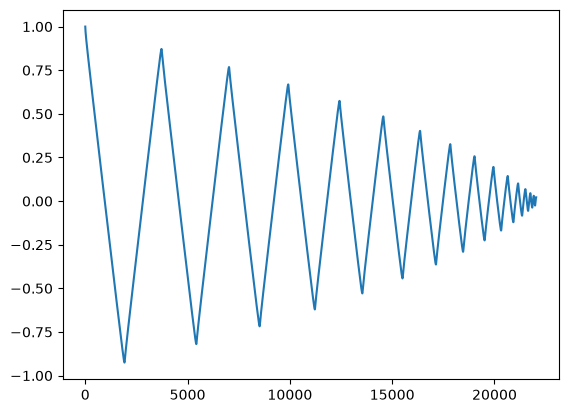

In [12]:
plt.plot(plt_theta)